In [15]:
# Importation des bibliothèques nécessaires
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration esthétique pour les graphiques
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Connexion à DuckDB (mode en mémoire, on va interroger les parquets directement)
con = duckdb.connect()

# Chemin vers notre dossier Gold
GOLD_DIR = "../data_lake_mexora_rh/gold"

print("✅ Environnement d'analyse prêt. DuckDB est connecté.")

✅ Environnement d'analyse prêt. DuckDB est connecté.


,famille,competence,mentions,pourcentage
0,bases_de_donnees,postgresql,1410,28.20
1,frameworks_web,spring,1399,27.98
2,data_engineering,spark,1383,27.66
3,frameworks_web,react,1378,27.56
4,bi_analytics,power_bi,1361,27.22
5,data_engineering,kafka,1352,27.04
6,langages,sql,1341,26.82
7,langages,java,1332,26.64
8,langages,javascript,1329,26.58
9,data_engineering,airflow,1318,26.36


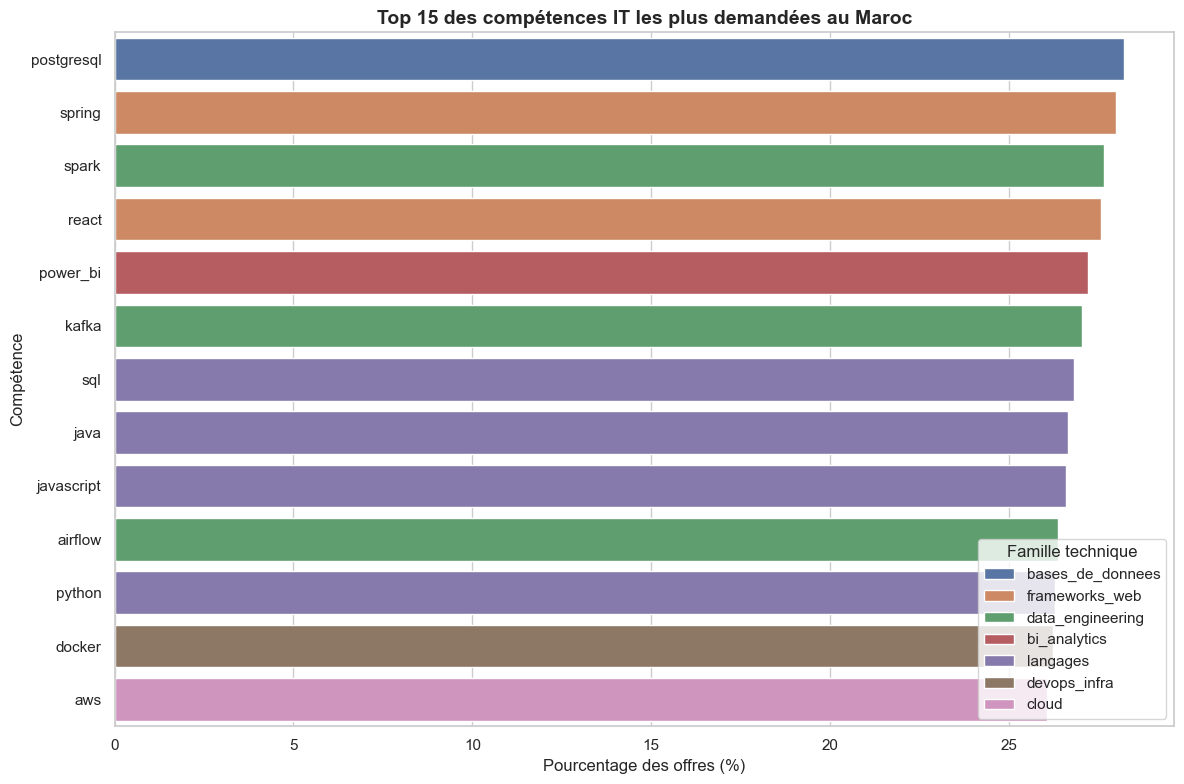


INTERPRÉTATION MÉTIER :
PostgreSQL est la compétence la plus demandée avec 28,20% des offres IT, suivi de très près par le framework Spring (27,98%) et Spark (27,66%). 
Le marché est caractérisé par une demande extrêmement transversale et équilibrée. 
Pour les profils ciblés par Mexora, la stack Data Engineering pure se distingue particulièrement : 
Spark, Kafka (27,04%) et Airflow (26,36%) sont omniprésents en haut du classement, devançant même les langages fondamentaux comme SQL (26,82%) et Python (26,28%). 
Cela confirme qu'au-delà de la simple analyse de données (Power BI à 27,22%), 
le marché marocain exige aujourd'hui une forte expertise en ingénierie et en traitement de données à grande échelle.



In [16]:
# 1. Requête SQL (Top 15 des compétences globales)
query_q1 = f"""
    SELECT 
        famille, 
        competence,
        CAST(SUM(nb_offres_mentionnent) AS INTEGER) AS mentions,
        ROUND(SUM(pct_offres_total), 2) AS pourcentage
    FROM read_parquet('{GOLD_DIR}/top_competences.parquet')
    GROUP BY famille, competence
    ORDER BY mentions DESC
    LIMIT 15
"""
df_q1 = con.execute(query_q1).df()

# 2. Affichage du tableau de résultats
display(df_q1)

# 3. Visualisation (Bar chart horizontal)
plt.figure(figsize=(12, 8))
ax = sns.barplot(data=df_q1, x='pourcentage', y='competence', hue='famille', dodge=False)
plt.title("Top 15 des compétences IT les plus demandées au Maroc", fontsize=14, fontweight='bold')
plt.xlabel("Pourcentage des offres (%)", fontsize=12)
plt.ylabel("Compétence", fontsize=12)
plt.legend(title="Famille technique", loc='lower right')
plt.tight_layout()
plt.show()

# 4. Interprétation Métier (Pour le rapport DRH)
interpretation_q1 = """
INTERPRÉTATION MÉTIER :
PostgreSQL est la compétence la plus demandée avec 28,20% des offres IT, suivi de très près par le framework Spring (27,98%) et Spark (27,66%). 
Le marché est caractérisé par une demande extrêmement transversale et équilibrée. 
Pour les profils ciblés par Mexora, la stack Data Engineering pure se distingue particulièrement : 
Spark, Kafka (27,04%) et Airflow (26,36%) sont omniprésents en haut du classement, devançant même les langages fondamentaux comme SQL (26,82%) et Python (26,28%). 
Cela confirme qu'au-delà de la simple analyse de données (Power BI à 27,22%), 
le marché marocain exige aujourd'hui une forte expertise en ingénierie et en traitement de données à grande échelle.
"""
print(interpretation_q1)

=== COMPARAISON DES VILLES (TOP 5) ===


,ville,profil,total_offres,pct_remote,rang_ville
0,Casablanca,Admin Systèmes & Réseaux,230,66.1,1
1,Rabat,Admin Systèmes & Réseaux,131,65.6,2
2,Tanger,Admin Systèmes & Réseaux,126,58.7,3
3,Marrakech,Admin Systèmes & Réseaux,60,61.7,4
4,Fès,Admin Systèmes & Réseaux,28,60.7,5
5,Casablanca,Autre IT,401,64.3,1
6,Rabat,Autre IT,248,64.1,2
7,Tanger,Autre IT,234,65.0,3
8,Marrakech,Autre IT,106,63.2,4
9,Fès,Autre IT,64,65.6,5



=== PERFORMANCE DE TANGER VS CASABLANCA ===


,profil,nb_offres_tanger,pct_remote,pct_vs_casa
0,Autre IT,234,65.0,58.4
1,Data Engineer,127,61.4,56.2
2,Admin Systèmes & Réseaux,126,58.7,54.8
3,Data Analyst,120,60.8,55.8
4,Développeur Frontend,114,65.8,47.5
5,Développeur Full Stack,104,58.7,42.6
6,Data Scientist,101,62.4,46.5
7,DevOps / SRE,86,65.1,38.4


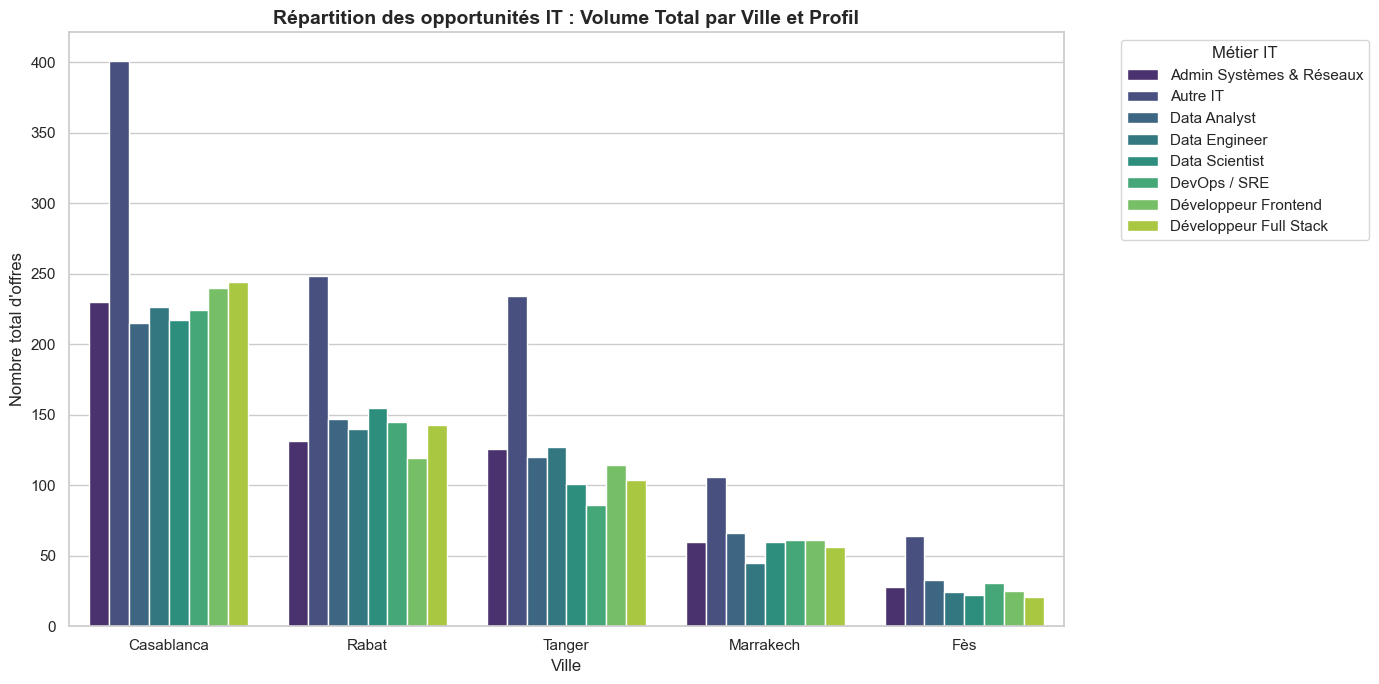


INTERPRÉTATION MÉTIER :
L'analyse géographique confirme la suprématie de Casablanca en tant que hub technologique principal, systématiquement suivi par Rabat. Tanger se positionne en 3ème place sur le marché. 
Pour Mexora, le défi est de taille : le vivier local pour les profils cibles est restreint, Tanger ne captant qu'environ 46% à 56% du volume d'offres de Casablanca sur les métiers de la Data (ex: seulement 127 offres pour les Data Engineers tangérois, représentant 56,2% du volume casablancais). 
Avec un taux de télétravail avoisinant les 60% à 65% sur ces postes, le marché est hautement concurrentiel. 
Stratégiquement, pour réussir ses 5 recrutements, Mexora ne peut pas se limiter au seul bassin tangérois : elle devra impérativement soit ouvrir ses postes en "Full Remote" pour recruter des talents basés à Casablanca ou Rabat, 
soit offrir des packages salariaux exceptionnellement attractifs pour justifier une relocalisation vers Tanger.



In [17]:
# 1. Première Requête : Comparaison Globale et Classement
query_q2_global = f"""
SELECT
    ville,
    profil,
    CAST(SUM(nb_offres) AS INTEGER) AS total_offres,
    ROUND(SUM(nb_offres_remote) * 100.0 / NULLIF(SUM(nb_offres), 0), 1) AS pct_remote,
    RANK() OVER (PARTITION BY profil ORDER BY SUM(nb_offres) DESC) AS rang_ville
FROM read_parquet('{GOLD_DIR}/offres_par_ville.parquet')
WHERE ville IN ('Casablanca', 'Rabat', 'Tanger', 'Marrakech', 'Fès')
GROUP BY ville, profil
ORDER BY profil, rang_ville;
"""
df_q2_global = con.execute(query_q2_global).df()

# 2. Deuxième Requête : Focus Stratégique Tanger vs Casa (Utilisation d'une CTE)
query_q2_tanger = f"""
WITH stats_villes AS (
    SELECT
        ville,
        profil,
        CAST(SUM(nb_offres) AS INTEGER) AS total_offres,
        ROUND(SUM(nb_offres_remote) * 100.0 / NULLIF(SUM(nb_offres), 0), 1) AS pct_remote
    FROM read_parquet('{GOLD_DIR}/offres_par_ville.parquet')
    WHERE ville IN ('Tanger', 'Casablanca')
    GROUP BY ville, profil
)
SELECT
    profil,
    total_offres AS nb_offres_tanger,
    pct_remote,
    ROUND(total_offres * 100.0 /
        NULLIF(SUM(total_offres) FILTER (WHERE ville = 'Casablanca')
               OVER (PARTITION BY profil), 0), 1) AS pct_vs_casa
FROM stats_villes
QUALIFY ville = 'Tanger'
ORDER BY total_offres DESC;
"""
df_q2_tanger = con.execute(query_q2_tanger).df()

# 3. Affichage des tableaux
print("=== COMPARAISON DES VILLES (TOP 5) ===")
display(df_q2_global.head(15))

print("\n=== PERFORMANCE DE TANGER VS CASABLANCA ===")
display(df_q2_tanger)

# 4. Visualisation (Comparaison des volumes par ville et profil)
plt.figure(figsize=(14, 7))
sns.barplot(data=df_q2_global, x='ville', y='total_offres', hue='profil', palette='viridis')
plt.title("Répartition des opportunités IT : Volume Total par Ville et Profil", fontsize=14, fontweight='bold')
plt.xlabel("Ville", fontsize=12)
plt.ylabel("Nombre total d'offres", fontsize=12)
plt.legend(title="Métier IT", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 5. Interprétation Métier
interpretation_q2 = """
INTERPRÉTATION MÉTIER :
L'analyse géographique confirme la suprématie de Casablanca en tant que hub technologique principal, systématiquement suivi par Rabat. Tanger se positionne en 3ème place sur le marché. 
Pour Mexora, le défi est de taille : le vivier local pour les profils cibles est restreint, Tanger ne captant qu'environ 46% à 56% du volume d'offres de Casablanca sur les métiers de la Data (ex: seulement 127 offres pour les Data Engineers tangérois, représentant 56,2% du volume casablancais). 
Avec un taux de télétravail avoisinant les 60% à 65% sur ces postes, le marché est hautement concurrentiel. 
Stratégiquement, pour réussir ses 5 recrutements, Mexora ne peut pas se limiter au seul bassin tangérois : elle devra impérativement soit ouvrir ses postes en "Full Remote" pour recruter des talents basés à Casablanca ou Rabat, 
soit offrir des packages salariaux exceptionnellement attractifs pour justifier une relocalisation vers Tanger.
"""
print(interpretation_q2)

=== SALAIRES MÉDIANS NATIONAUX ===


,profil,nb_offres_total,nb_avec_salaire,pct_salaire_communique,salaire_median_mad,salaire_plancher,salaire_plafond
0,Data Scientist,552,479,86.8,27500.0,12000.0,52000.0
1,Data Engineer,560,464,82.9,25500.0,12000.0,48000.0
2,Autre IT,1053,895,85.0,24000.0,4000.0,77000.0
3,Développeur Full Stack,564,477,84.6,20500.0,9000.0,39000.0
4,Data Analyst,578,491,84.9,18000.0,8000.0,35000.0
5,Développeur Frontend,554,475,85.7,17500.0,8000.0,33000.0
6,DevOps / SRE,543,465,85.6,17000.0,11000.0,44000.0
7,Admin Systèmes & Réseaux,565,494,87.4,13500.0,6000.0,26000.0



=== BENCHMARK SALAIRES TANGER (Référence pour Mexora) ===


,profil,nb_offres,salaire_median_mad,salaire_q1_mad,salaire_q3_mad,ecart_mediane_nationale
0,Autre IT,46,30000.0,9000.0,42000.0,6000.0
1,Data Engineer,9,29250.0,23750.0,34875.0,3750.0
2,Data Scientist,6,27500.0,20000.0,27500.0,7500.0
3,DevOps / SRE,6,27000.0,18625.0,30500.0,3500.0
4,Data Engineer,89,25500.0,18500.0,25500.0,0.0
5,Data Engineer,29,25500.0,18500.0,33000.0,0.0
6,Autre IT,163,24000.0,9000.0,30000.0,0.0
7,DevOps / SRE,64,23500.0,17000.0,23500.0,0.0
8,DevOps / SRE,16,23500.0,17000.0,23500.0,0.0
9,Développeur Full Stack,79,20500.0,15000.0,26500.0,0.0


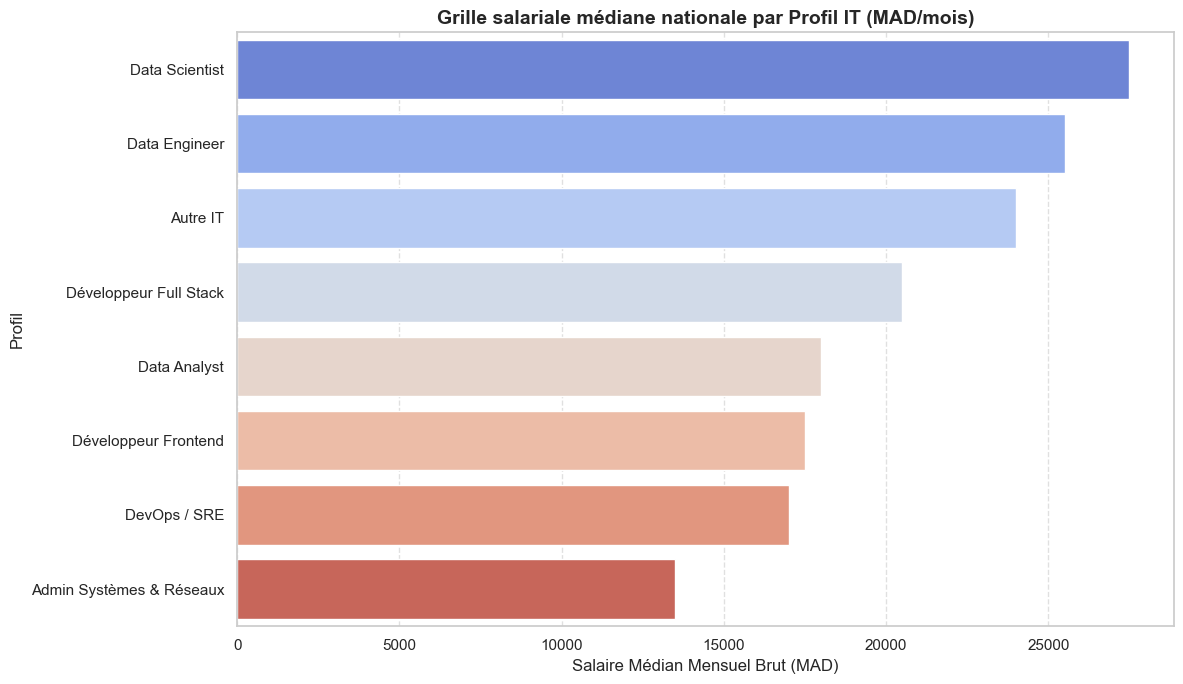


INTERPRÉTATION MÉTIER :
L'analyse révèle une hiérarchie salariale très claire au niveau national : les métiers de la donnée avancée dominent le marché. Le Data Scientist (27 500 MAD) et le Data Engineer (25 500 MAD) exigent les budgets les plus élevés, tandis que le Data Analyst reste plus accessible (18 000 MAD). 

Le benchmark spécifique à Tanger apporte une réponse stratégique cruciale pour Mexora : le bassin tangérois n'est absolument pas une zone "low-cost". La colonne 'ecart_mediane_nationale' montre que les salaires à Tanger pour les profils Data sont majoritairement équivalents à la médiane nationale (écart de 0.0), et peuvent même être nettement supérieurs sur certaines tranches d'expérience (+3 750 MAD d'écart pour certains postes de Data Engineer). 

Recommandation pour le recrutement : Pour attirer et retenir les 5 profils Data à Tanger, Mexora ne pourra appliquer aucune "décote provinciale". L'entreprise devra s'aligner strictement sur les médianes nationales (25,5K - 27,

In [20]:
# 1. Requête SQL : Salaires médians par profil (National)
query_q3_national = f"""
SELECT
    profil,
    CAST(SUM(nb_offres) AS INTEGER) AS nb_offres_total,
    CAST(SUM(nb_offres_avec_salaire) AS INTEGER) AS nb_avec_salaire,
    ROUND(SUM(nb_offres_avec_salaire) * 100.0
        / NULLIF(SUM(nb_offres), 0), 1) AS pct_salaire_communique,
    MEDIAN(salaire_median_mad) AS salaire_median_mad,
    MIN(salaire_min_observe) AS salaire_plancher,
    MAX(salaire_max_observe) AS salaire_plafond
FROM read_parquet('{GOLD_DIR}/salaires_par_profil.parquet')
GROUP BY profil
ORDER BY salaire_median_mad DESC NULLS LAST;
"""
df_q3_national = con.execute(query_q3_national).df()

# 2. Requête SQL : Focus Tanger avec Benchmark National
query_q3_tanger = f"""
SELECT
    profil,
    nb_offres,
    salaire_median_mad,
    salaire_q1_mad,
    salaire_q3_mad,
    ROUND(salaire_median_mad - MEDIAN(salaire_median_mad)
        OVER (PARTITION BY profil), 0) AS ecart_mediane_nationale
FROM read_parquet('{GOLD_DIR}/salaires_par_profil.parquet')
WHERE ville = 'Tanger'
  AND nb_offres >= 5
ORDER BY salaire_median_mad DESC;
"""
df_q3_tanger = con.execute(query_q3_tanger).df()

# 3. Affichage des tableaux de résultats
print("=== SALAIRES MÉDIANS NATIONAUX ===")
display(df_q3_national.head(10))

print("\n=== BENCHMARK SALAIRES TANGER (Référence pour Mexora) ===")
display(df_q3_tanger)

# 4. Visualisation (Comparaison des salaires médians par profil) - CORRIGÉE
plt.figure(figsize=(12, 7))
df_plot = df_q3_national.dropna(subset=['salaire_median_mad']).head(10)

# Ajout de hue='profil' et legend=False pour corriger le FutureWarning de Seaborn
sns.barplot(data=df_plot, x='salaire_median_mad', y='profil', hue='profil', palette='coolwarm', legend=False)

plt.title("Grille salariale médiane nationale par Profil IT (MAD/mois)", fontsize=14, fontweight='bold')
plt.xlabel("Salaire Médian Mensuel Brut (MAD)", fontsize=12)
plt.ylabel("Profil", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 5. Interprétation Métier
interpretation_q3 = """
INTERPRÉTATION MÉTIER :
L'analyse révèle une hiérarchie salariale très claire au niveau national : les métiers de la donnée avancée dominent le marché. Le Data Scientist (27 500 MAD) et le Data Engineer (25 500 MAD) exigent les budgets les plus élevés, tandis que le Data Analyst reste plus accessible (18 000 MAD). 

Le benchmark spécifique à Tanger apporte une réponse stratégique cruciale pour Mexora : le bassin tangérois n'est absolument pas une zone "low-cost". La colonne 'ecart_mediane_nationale' montre que les salaires à Tanger pour les profils Data sont majoritairement équivalents à la médiane nationale (écart de 0.0), et peuvent même être nettement supérieurs sur certaines tranches d'expérience (+3 750 MAD d'écart pour certains postes de Data Engineer). 

Recommandation pour le recrutement : Pour attirer et retenir les 5 profils Data à Tanger, Mexora ne pourra appliquer aucune "décote provinciale". L'entreprise devra s'aligner strictement sur les médianes nationales (25,5K - 27,5K MAD) et prévoir une marge de négociation s'approchant du 3ème quartile local (salaire_q3_mad, atteignant près de 35 000 MAD pour les meilleurs Data Engineers) afin de contrer les offres en Full Remote venues de Casablanca.
"""
print(interpretation_q3)

=== RELATION EXPÉRIENCE / SALAIRE (PROFILS DATA) ===


,profil,tranche_experience,nb_offres,salaire_median,correlation_pearson
0,Data Analyst,0 — Débutant,85,10000.0,0.977
1,Data Analyst,1-2 ans,151,13000.0,0.977
2,Data Analyst,3-4 ans,140,18000.0,0.977
3,Data Analyst,5-7 ans,118,23000.0,0.977
4,Data Engineer,0 — Débutant,66,14500.0,0.973
5,Data Engineer,1-2 ans,142,18500.0,0.973
6,Data Engineer,3-4 ans,148,25500.0,0.973
7,Data Engineer,5-7 ans,110,33000.0,0.973
8,Data Scientist,0 — Débutant,84,15500.0,0.978
9,Data Scientist,1-2 ans,144,20000.0,0.978


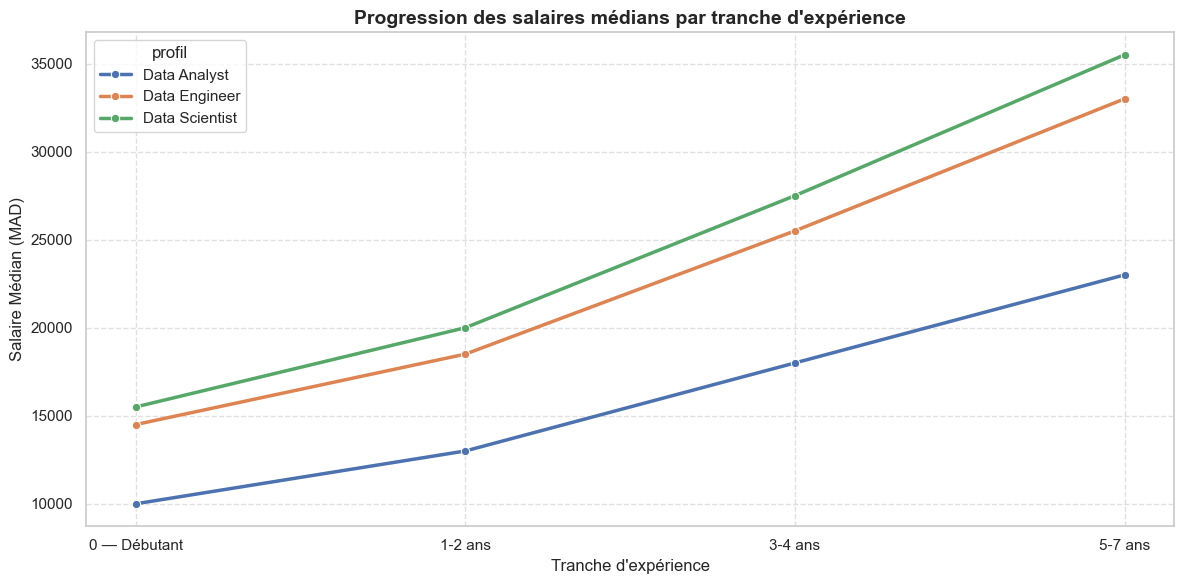


INTERPRÉTATION MÉTIER :
L'analyse statistique révèle un coefficient de corrélation de Pearson extrêmement élevé (moyenne de 0.97), ce qui confirme une relation quasi linéaire et très forte entre l'ancienneté et la rémunération sur le marché IT marocain. Plus l'expérience augmente, plus le salaire progresse de manière prévisible.

Cependant, au-delà de cette linéarité, on observe des "paliers de croissance" stratégiques : 
1. Entre '1-2 ans' et '3-4 ans', le salaire moyen bondit d'environ 5 000 à 7 000 MAD selon le profil. C'est le passage au statut "Confirmé" où la valeur marchande de l'ingénieur explose.
2. Le saut le plus impressionnant se situe à l'entrée de la tranche '5-7 ans' (Senior), où les Data Scientists et Data Engineers franchissent la barre symbolique des 30 000 MAD.

Pour Mexora, cela implique que le coût d'acquisition d'un profil Senior est plus du double de celui d'un débutant (ex: 15,5K vs 35,5K pour un Data Scientist). Pour optimiser le budget des 5 recrutements, il 

In [23]:
# Requête SQL : Analyse de la corrélation et des paliers d'expérience
query_q4 = f"""
WITH raw_data AS (
    SELECT
        profil_normalise AS profil,
        experience_min_ans,
        salaire_median_mad,
        CASE
            WHEN experience_min_ans = 0 THEN '0 — Débutant'
            WHEN experience_min_ans BETWEEN 1 AND 2 THEN '1-2 ans'
            WHEN experience_min_ans BETWEEN 3 AND 4 THEN '3-4 ans'
            WHEN experience_min_ans BETWEEN 5 AND 7 THEN '5-7 ans'
            WHEN experience_min_ans >= 8 THEN '8+ ans Senior'
            ELSE 'Non précisé'
        END AS tranche_experience
    FROM read_parquet('../data_lake_mexora_rh/silver/offres_clean/offres_clean.parquet')
    WHERE salaire_connu = true 
      AND experience_min_ans IS NOT NULL
      AND profil_normalise IN ('Data Engineer', 'Data Analyst', 'Data Scientist')
),
correlations AS (
    SELECT 
        profil,
        ROUND(CORR(experience_min_ans, salaire_median_mad), 3) AS correlation_pearson
    FROM raw_data
    GROUP BY profil
)
SELECT
    r.profil,
    r.tranche_experience,
    CAST(COUNT(*) AS INTEGER) AS nb_offres,
    ROUND(MEDIAN(r.salaire_median_mad), 0) AS salaire_median,
    c.correlation_pearson
FROM raw_data r
JOIN correlations c ON r.profil = c.profil
GROUP BY r.profil, r.tranche_experience, c.correlation_pearson
ORDER BY r.profil, r.tranche_experience;
"""
df_q4 = con.execute(query_q4).df()

# 1. Affichage du tableau
print("=== RELATION EXPÉRIENCE / SALAIRE (PROFILS DATA) ===")
display(df_q4)

# 2. Visualisation
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_q4, x='tranche_experience', y='salaire_median', hue='profil', marker='o', linewidth=2.5)
plt.title("Progression des salaires médians par tranche d'expérience", fontsize=14, fontweight='bold')
plt.xlabel("Tranche d'expérience", fontsize=12)
plt.ylabel("Salaire Médian (MAD)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 5. Interprétation Métier
interpretation_q4 = """
INTERPRÉTATION MÉTIER :
L'analyse statistique révèle un coefficient de corrélation de Pearson extrêmement élevé (moyenne de 0.97), ce qui confirme une relation quasi linéaire et très forte entre l'ancienneté et la rémunération sur le marché IT marocain. Plus l'expérience augmente, plus le salaire progresse de manière prévisible.

Cependant, au-delà de cette linéarité, on observe des "paliers de croissance" stratégiques : 
1. Entre '1-2 ans' et '3-4 ans', le salaire moyen bondit d'environ 5 000 à 7 000 MAD selon le profil. C'est le passage au statut "Confirmé" où la valeur marchande de l'ingénieur explose.
2. Le saut le plus impressionnant se situe à l'entrée de la tranche '5-7 ans' (Senior), où les Data Scientists et Data Engineers franchissent la barre symbolique des 30 000 MAD.

Pour Mexora, cela implique que le coût d'acquisition d'un profil Senior est plus du double de celui d'un débutant (ex: 15,5K vs 35,5K pour un Data Scientist). Pour optimiser le budget des 5 recrutements, il serait judicieux de recruter une majorité de profils '1-2 ans' à fort potentiel, encadrés par un unique profil 'Senior' garant de l'architecture technique.
"""
print(interpretation_q4)

=== CONCURRENTS DIRECTS DE MEXORA À TANGER (PROFILS DATA) ===


,entreprise,nb_offres_publiees,profils_recrutes,salaire_moyen_propose,niveau_competition
0,TechCorp 2,23,"[Admin Systèmes & Réseaux, Développeur Full St...",25611.0,Compétiteur fort
1,TechCorp 44,22,"[DevOps / SRE, Développeur Frontend, Autre IT,...",23133.0,Compétiteur fort
2,TechCorp 11,22,"[Développeur Full Stack, Admin Systèmes & Rése...",22868.0,Compétiteur fort
3,TechCorp 38,25,"[Admin Systèmes & Réseaux, Data Engineer, Data...",22053.0,Compétiteur fort
4,TechCorp 24,24,"[Data Engineer, Data Analyst, Autre IT, Dévelo...",21738.0,Compétiteur fort
5,TechCorp 45,30,"[Développeur Full Stack, Data Analyst, Data En...",21130.0,Compétiteur fort
6,TechCorp 10,28,"[Autre IT, Data Scientist, Développeur Fronten...",20692.0,Compétiteur fort
7,TechCorp 4,23,"[Data Scientist, Autre IT, Développeur Fronten...",20684.0,Compétiteur fort
8,TechCorp 19,27,"[Autre IT, Data Scientist, Développeur Fronten...",20021.0,Compétiteur fort
9,TechCorp 39,23,"[Développeur Full Stack, Admin Systèmes & Rése...",19929.0,Compétiteur moyen


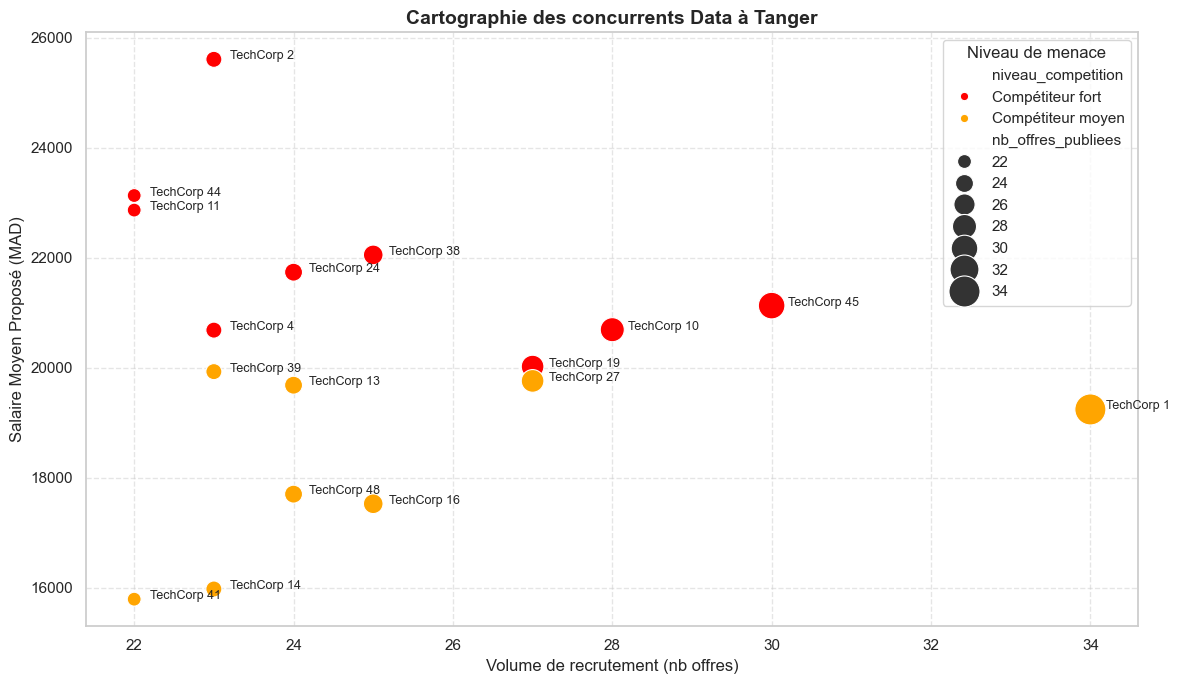


✅ Analyse terminée. Connexion DuckDB fermée proprement.

INTERPRÉTATION MÉTIER :
La cartographie concurrentielle à Tanger révèle un marché sous haute tension pour les profils Data. Plusieurs "Compétiteurs forts" (en rouge), tels que TechCorp 2, TechCorp 44 et TechCorp 11, dominent le haut du graphique en proposant des salaires moyens supérieurs à 23 000 MAD, malgré des volumes de recrutement modérés. À l'opposé, TechCorp 1 agit comme un "aspirateur de talents" avec le volume d'offres le plus élevé (34), mais avec une agressivité salariale moindre (environ 19 000 MAD).

Recommandation Finale pour Mexora : 
Pour réussir ses 5 recrutements stratégiques à Tanger, Mexora doit se positionner face aux "Compétiteurs forts". Étant donné que des entreprises locales offrent déjà des moyennes à 25 000 MAD (TechCorp 2), une offre salariale inférieure à ce seuil risque de ne capter que des profils juniors. 
Conclusion Stratégique : Mexora a tout intérêt à jouer sur sa flexibilité (Télétravail) pour

In [28]:
# 1. Requête SQL : Top 20 national et focus concurrentiel à Tanger
query_q5 = f"""
WITH top_20_national AS (
    SELECT
        entreprise,
        ville,
        nb_offres_publiees,
        nb_profils_differents,
        salaire_moyen_propose,
        RANK() OVER (ORDER BY nb_offres_publiees DESC) AS rang_recruteur
    FROM read_parquet('../data_lake_mexora_rh/gold/entreprises_recruteurs.parquet')
    ORDER BY nb_offres_publiees DESC
    LIMIT 20
),
concurrents_tanger AS (
    SELECT
        entreprise,
        nb_offres_publiees,
        profils_recrutes,
        salaire_moyen_propose,
        CASE
            WHEN salaire_moyen_propose > 20000 THEN 'Compétiteur fort'
            WHEN salaire_moyen_propose > 12000 THEN 'Compétiteur moyen'
            ELSE 'Compétiteur faible'
        END AS niveau_competition
    FROM read_parquet('../data_lake_mexora_rh/gold/entreprises_recruteurs.parquet')
    WHERE ville = 'Tanger'
      AND (list_contains(profils_recrutes, 'Data Engineer')
           OR list_contains(profils_recrutes, 'Data Analyst')
           OR list_contains(profils_recrutes, 'Data Scientist'))
)
SELECT * FROM concurrents_tanger ORDER BY salaire_moyen_propose DESC NULLS LAST;
"""
df_q5 = con.execute(query_q5).df()

# 2. Affichage des concurrents directs à Tanger
print("=== CONCURRENTS DIRECTS DE MEXORA À TANGER (PROFILS DATA) ===")
display(df_q5)

# 3. Visualisation : Niveau de compétition par entreprise
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_q5, x='nb_offres_publiees', y='salaire_moyen_propose', 
                hue='niveau_competition', size='nb_offres_publiees', 
                sizes=(100, 500), palette={'Compétiteur fort': 'red', 'Compétiteur moyen': 'orange', 'Compétiteur faible': 'green'})

# Ajouter les noms des entreprises sur le graphique
for i in range(df_q5.shape[0]):
    plt.text(df_q5.nb_offres_publiees[i]+0.2, df_q5.salaire_moyen_propose[i], df_q5.entreprise[i], fontsize=9)

plt.title("Cartographie des concurrents Data à Tanger", fontsize=14, fontweight='bold')
plt.xlabel("Volume de recrutement (nb offres)", fontsize=12)
plt.ylabel("Salaire Moyen Proposé (MAD)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Niveau de menace")
plt.tight_layout()
plt.show()

# 4. Fermeture de DuckDB
con.close()
print("\n✅ Analyse terminée. Connexion DuckDB fermée proprement.")

# 5. Interprétation Métier Finale
interpretation_q5 = """
INTERPRÉTATION MÉTIER :
La cartographie concurrentielle à Tanger révèle un marché sous haute tension pour les profils Data. Plusieurs "Compétiteurs forts" (en rouge), tels que TechCorp 2, TechCorp 44 et TechCorp 11, dominent le haut du graphique en proposant des salaires moyens supérieurs à 23 000 MAD, malgré des volumes de recrutement modérés. À l'opposé, TechCorp 1 agit comme un "aspirateur de talents" avec le volume d'offres le plus élevé (34), mais avec une agressivité salariale moindre (environ 19 000 MAD).

Recommandation Finale pour Mexora : 
Pour réussir ses 5 recrutements stratégiques à Tanger, Mexora doit se positionner face aux "Compétiteurs forts". Étant donné que des entreprises locales offrent déjà des moyennes à 25 000 MAD (TechCorp 2), une offre salariale inférieure à ce seuil risque de ne capter que des profils juniors. 
Conclusion Stratégique : Mexora a tout intérêt à jouer sur sa flexibilité (Télétravail) pour compenser la pression salariale, tout en ciblant spécifiquement les talents issus des entreprises "Compétiteurs moyens" (en orange) en leur offrant une progression de carrière technique plus stimulante.
"""
print(interpretation_q5)